In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
from pathlib import Path
import os

# 👇 this folder name must match exactly the one in your Drive
BASE_DIR = Path("/content/drive/MyDrive/crypto_voltality_risk_analyzer_project")
DATA_DIR = BASE_DIR / "data"

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("\nFiles in DATA_DIR:")
print(os.listdir(DATA_DIR))


BASE_DIR: /content/drive/MyDrive/crypto_voltality_risk_analyzer_project
DATA_DIR: /content/drive/MyDrive/crypto_voltality_risk_analyzer_project/data

Files in DATA_DIR:
['coin_USDCoin.csv', 'coin_CryptocomCoin.csv', 'coin_Dogecoin.csv', 'coin_Tron.csv', 'coin_Bitcoin.csv', 'coin_XRP.csv', 'coin_EOS.csv', 'coin_Monero.csv', 'coin_BinanceCoin.csv', 'coin_Solana.csv', 'coin_ChainLink.csv', 'coin_Litecoin.csv', 'coin_Cardano.csv', 'coin_Aave.csv', 'coin_Polkadot.csv', 'coin_Iota.csv', 'coin_Cosmos.csv', 'coin_Uniswap.csv', 'coin_WrappedBitcoin.csv', 'coin_Ethereum.csv', 'coin_Stellar.csv', 'coin_NEM.csv', 'coin_Tether.csv', 'combined_kaggle.csv']


In [3]:
import pandas as pd
import numpy as np
import logging

LOG_FILE = BASE_DIR / "logs_module1.txt"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s: %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)
logger.info("Module 1 – Data acquisition & preprocessing started")


In [4]:
SYMBOL_FILES = {
    "BTC": "coin_Bitcoin.csv",
    "ETH": "coin_Ethereum.csv",
    "SOL": "coin_Solana.csv",
    "ADA": "coin_Cardano.csv",
    "DOGE": "coin_Dogecoin.csv",
}
SYMBOL_FILES


{'BTC': 'coin_Bitcoin.csv',
 'ETH': 'coin_Ethereum.csv',
 'SOL': 'coin_Solana.csv',
 'ADA': 'coin_Cardano.csv',
 'DOGE': 'coin_Dogecoin.csv'}

In [5]:
def load_crypto_price(filename: str) -> pd.DataFrame:
    """
    Load one crypto CSV from DATA_DIR and return a clean DataFrame:
    index: date (datetime.date)
    column: close (float)
    """
    path = DATA_DIR / filename
    logger.info(f"Loading {path}")

    df = pd.read_csv(path)

    # show first few rows the first time you run this
    display(df.head())

    # most Kaggle crypto files use 'Date' and 'Close'
    # change these names if your columns are different
    df['Date'] = pd.to_datetime(df['Date'])
    df['Date'] = df['Date'].dt.date          # keep only date
    df['Close'] = df['Close'].astype(float)  # ensure numeric

    df = df[['Date', 'Close']].rename(columns={'Date': 'date', 'Close': 'close'})
    df = df.set_index('date').sort_index()

    return df


In [6]:
crypto_prices = {}

for symbol, filename in SYMBOL_FILES.items():
    df = load_crypto_price(filename)
    crypto_prices[symbol] = df
    logger.info(f"{symbol}: {df.shape[0]} rows from {df.index.min()} to {df.index.max()}")

crypto_prices['BTC'].head()


,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Bitcoin,BTC,2013-04-29 23:59:59,147.488007,134.000000,134.444000,144.539993,0.0,1.603769e+09
1,2,Bitcoin,BTC,2013-04-30 23:59:59,146.929993,134.050003,144.000000,139.000000,0.0,1.542813e+09
2,3,Bitcoin,BTC,2013-05-01 23:59:59,139.889999,107.720001,139.000000,116.989998,0.0,1.298955e+09
3,4,Bitcoin,BTC,2013-05-02 23:59:59,125.599998,92.281898,116.379997,105.209999,0.0,1.168517e+09
4,5,Bitcoin,BTC,2013-05-03 23:59:59,108.127998,79.099998,106.250000,97.750000,0.0,1.085995e+09


,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Ethereum,ETH,2015-08-08 23:59:59,2.798810,0.714725,2.793760,0.753325,674188.0,4.548689e+07
1,2,Ethereum,ETH,2015-08-09 23:59:59,0.879810,0.629191,0.706136,0.701897,532170.0,4.239957e+07
2,3,Ethereum,ETH,2015-08-10 23:59:59,0.729854,0.636546,0.713989,0.708448,405283.0,4.281836e+07
3,4,Ethereum,ETH,2015-08-11 23:59:59,1.131410,0.663235,0.708087,1.067860,1463100.0,6.456929e+07
4,5,Ethereum,ETH,2015-08-12 23:59:59,1.289940,0.883608,1.058750,1.217440,2150620.0,7.364501e+07


,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Solana,SOL,2020-04-11 23:59:59,1.049073,0.765020,0.951054,0.776819,4.386244e+07,0.0
1,2,Solana,SOL,2020-04-12 23:59:59,0.956670,0.762426,0.785448,0.882507,3.873690e+07,0.0
2,3,Solana,SOL,2020-04-13 23:59:59,0.891603,0.773976,0.890760,0.777832,1.821129e+07,0.0
3,4,Solana,SOL,2020-04-14 23:59:59,0.796472,0.628169,0.777832,0.661925,1.674761e+07,0.0
4,5,Solana,SOL,2020-04-15 23:59:59,0.704964,0.621531,0.669289,0.646651,1.307528e+07,0.0


,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Cardano,ADA,2017-10-02 23:59:59,0.030088,0.019969,0.024607,0.025932,57641300.0,6.288991e+08
1,2,Cardano,ADA,2017-10-03 23:59:59,0.027425,0.020690,0.025757,0.020816,16997800.0,5.396927e+08
2,3,Cardano,ADA,2017-10-04 23:59:59,0.022806,0.020864,0.020864,0.021931,9000050.0,5.686195e+08
3,4,Cardano,ADA,2017-10-05 23:59:59,0.022154,0.020859,0.021951,0.021489,5562510.0,5.571390e+08
4,5,Cardano,ADA,2017-10-06 23:59:59,0.021542,0.018360,0.021359,0.018539,7780710.0,4.806646e+08


,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Dogecoin,DOGE,2013-12-16 23:59:59,0.000866,0.000150,0.000299,0.000205,0.0,1.509085e+06
1,2,Dogecoin,DOGE,2013-12-17 23:59:59,0.000289,0.000116,0.000207,0.000269,0.0,2.169688e+06
2,3,Dogecoin,DOGE,2013-12-18 23:59:59,0.000362,0.000205,0.000267,0.000362,0.0,3.188943e+06
3,4,Dogecoin,DOGE,2013-12-19 23:59:59,0.001520,0.000328,0.000395,0.001162,0.0,1.115034e+07
4,5,Dogecoin,DOGE,2013-12-20 23:59:59,0.001143,0.000662,0.001143,0.000704,0.0,7.284337e+06


,close
date,
2013-04-29,144.539993
2013-04-30,139.000000
2013-05-01,116.989998
2013-05-02,105.209999
2013-05-03,97.750000


In [7]:
# Combine: each column = one coin, index = date
prices = pd.concat(
    [df.rename(columns={'close': symbol}) for symbol, df in crypto_prices.items()],
    axis=1
).sort_index()

# Ensure daily frequency (fill missing days with NaN, don’t invent values)
prices = prices.asfreq('D')

prices.head(), prices.tail()


(                   BTC  ETH  SOL  ADA  DOGE
 date                                       
 2013-04-29  144.539993  NaN  NaN  NaN   NaN
 2013-04-30  139.000000  NaN  NaN  NaN   NaN
 2013-05-01  116.989998  NaN  NaN  NaN   NaN
 2013-05-02  105.209999  NaN  NaN  NaN   NaN
 2013-05-03   97.750000  NaN  NaN  NaN   NaN,
                      BTC          ETH        SOL       ADA      DOGE
 date                                                                
 2021-07-02  33897.048590  2150.040364  34.020482  1.394397  0.245264
 2021-07-03  34668.548402  2226.114282  34.478816  1.406836  0.246411
 2021-07-04  35287.779766  2321.724112  34.310601  1.458184  0.246483
 2021-07-05  33746.002456  2198.582464  32.984588  1.404898  0.231614
 2021-07-06  34235.193451  2324.679449  34.269140  1.418053  0.234422)

In [8]:
# Save as CSV and Parquet (professional)
prices.to_csv(DATA_DIR / "prices_clean.csv", index_label="date")
prices.to_parquet(DATA_DIR / "prices_clean.parquet")

logger.info("Saved prices_clean.csv and prices_clean.parquet")


<Figure size 1200x500 with 0 Axes>

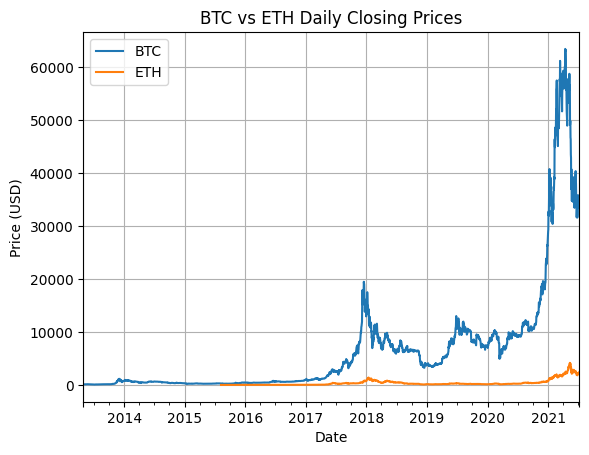

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
prices[['BTC', 'ETH']].plot()
plt.title("BTC vs ETH Daily Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()
